## Ayudantía 2
### Profesor: Elwin van 't Wout
### Ayudante: Alberto Almuna Morales (alberto.almuna@uc.cl)

Se propone el siguiente ejemplo a paralelizar utilizando Joblib:

In [1]:
import time as tm
import numpy as np

Utilizaremos la [fórmula de Haversine](https://en.wikipedia.org/wiki/Haversine_formula) para calcular distancias dadas las latitudes y longitudes de puntos:

In [2]:
def calculateHaversineDistance(latitude1, longitude1, latitude2, longitude2):
    earth_radius_km = 6371

    # Pasamos a radianes:
    latitude_dist = (latitude2 - latitude1) * np.pi / 180
    longitude_dist = (longitude2 - longitude1) * np.pi / 180

    # Aplicamos la fórmula:
    haversine_value = np.sin(latitude_dist / 2)**2 + \
        np.sin(longitude_dist / 2)**2
    haversine_value *= np.cos(latitude1 * np.pi / 180) * \
        np.cos(latitude2 * np.pi / 180)

    haversine_dist = 2 * \
        np.arcsin(np.sqrt(haversine_value)) * earth_radius_km

    return haversine_dist

Código secuencial:

In [10]:
t0 = tm.time()

coordinates = []
max_distance = -1

with open("coordenadas10000.txt", 'r') as file:

    file.readline() # Nos saltamos la primera línea

    for line in file:

        coordinates_info = line.strip().split(',')
        latitude = float(coordinates_info[0])
        longitude = float(coordinates_info[1])

        coordinates.append((latitude, longitude))


for coordinate1 in coordinates:
    for coordinate2 in coordinates:

        distance = calculateHaversineDistance(
            coordinate1[0], coordinate1[1], coordinate2[0], coordinate2[1])

        if distance > max_distance:
            max_distance = distance


t1 = tm.time()


print('Tiempo de ejecucion: ', t1-t0)
print('Distancia maxima: ', max_distance)

Tiempo de ejecucion:  589.8582360744476
Distancia maxima:  44.829257919253564


Propuesta código paralelo:

Al observar el código secuencial anterior, podemos notar que este se divide en dos partes: lectura de los datos (manejo de strings y crear las tuplas) y el cálculo de las distancias. A partir de lo anterior, hacemos un primer intento paralelo con dos funciones que hagan directamente estas tareas:

In [6]:
import time as tm
import numpy as np
from joblib import Parallel
from joblib import delayed

In [7]:
def readData(line):
    coordinates_info = line.strip().split(',')
    latitude = float(coordinates_info[0])
    longitude = float(coordinates_info[1])
    return (latitude, longitude)

In [8]:
def calculateDistances(coordinate1, original):
    # Calcula la distancia de coordinate1 con respecto a todas las otras (original)
    max_distance = -1

    for coordinate2 in original:

        distance = calculateHaversineDistance(
            coordinate1[0], coordinate1[1], coordinate2[0], coordinate2[1])

        if distance > max_distance:
            max_distance = distance
    return max_distance

Y corremos el código:

In [9]:
t0 = tm.time()
workers = 8

with open("coordenadas10000.txt", 'r') as file:
    # Leemos el archivo:
    file.readline() # Nos saltamos la primera línea
    file = file.readlines()

    # Creamos y ejecutamos los procesos paralelos:

    # Primero hacemos la lectura de la información:
    parallel_pool = Parallel(n_jobs=workers)
    parallel_readData = delayed(readData)
    parallel_tasks1 = map(parallel_readData, file)
    parallel_results1 = parallel_pool(parallel_tasks1)

    # Luego los cálculos de distancias
    parallel_calculateDistances = delayed(calculateDistances)
    parallel_tasks2 = [parallel_calculateDistances(i, parallel_results1) for i in parallel_results1]
    parallel_results2 = parallel_pool(parallel_tasks2)

    # Finalmente, calculamos la distancia máxima:
    max_distance = max(parallel_results2)

t1 = tm.time()

# Imprimimos las estadísticas:
print('Tiempo de ejecucion: ', t1-t0)
print('Distancia maxima: ', max_distance)

Tiempo de ejecucion:  251.38675999641418
Distancia maxima:  44.829257919253564


Observamos que se redujo bastante el tiempo de ejecución.

Código hecho por Daniel (año 2022):

Nos podemos dar cuenta que el código anterior repite muchos cálculos innecesarios, las distancia de $x$ a $y$ es la misma que de $y$ a $x$, por lo que nos podemos ahorrar operaciones con el siguiente código:

In [10]:
def max_dist(x,n):
    max = 0
    if n >= len(x):
        return 0
    for i in range(n,len(x)): # No calculamos la distancia con las coordenadas anteriores a la n-ésima
        dist = 0
        if n != i:
            dist = calculateHaversineDistance(x[i][0],x[i][1],x[n][0],x[n][1])
            if dist > max:
                max = dist
    return max

In [12]:
t0 = tm.time()
workers = 8

coordinates = []

with open("coordenadas10000.txt", 'r') as file:

    file.readline()

    for line in file:

        coordinates_info = line.strip().split(',')
        latitude = float(coordinates_info[0])
        longitude = float(coordinates_info[1])

        coordinates.append((latitude, longitude))
        
tasks = [delayed(max_dist)(coordinates,i) for i in range(len(coordinates))]

with Parallel(n_jobs=workers,  verbose=0, backend='loky') as parallel_pool:
    parallel_results = parallel_pool(tasks)
max_distance = np.max(parallel_results)
t1 = tm.time()


print('Tiempo de ejecucion: ', t1-t0)
print('Distancia maxima: ', max_distance)

Tiempo de ejecucion:  128.85008001327515
Distancia maxima:  44.829257919253564


Disminuyó a 128 segundos gracias al ahorro de operaciones!

Finalmente, podemos combinar las dos ideas anteriores:

In [13]:
t0 = tm.time()
workers = 8

with open("coordenadas10000.txt", 'r') as file:

    file.readline()

    # Lectura de datos en paralelo:
    parallel_pool = Parallel(n_jobs=workers)
    parallel_readData = delayed(readData)
    parallel_tasks1 = map(parallel_readData, file)
    coordinates = parallel_pool(parallel_tasks1)

    # Cálculos en paralelo pero sin repetir operaciones innecesarias:      
    tasks = [delayed(max_dist)(coordinates,i) for i in range(len(coordinates))]
    parallel_results = parallel_pool(tasks)
    max_distance = np.max(parallel_results)

t1 = tm.time()


print('Tiempo de ejecucion: ', t1-t0)
print('Distancia maxima: ', max_distance)

Tiempo de ejecucion:  130.2639775276184
Distancia maxima:  44.829257919253564


Notamos que no ganamos mucho al paralelizar también la lectura de datos debido a que el código secuencial ya es bastante rápido haciendo esto. Cabe destacar que, en caso de tener archivos más grandes o funciones más complejas de lectura, esto sí podría hacer una diferencia notoria.

## Gráfico de rendimiento:

Veamos un gráfico de tiempo de cómputo versus el número de trabajadores:

In [14]:
# Revisamos nuestro cpu_count

from joblib import cpu_count
print("Number of cores found by joblib:", cpu_count())

Number of cores found by joblib: 8


Creemos una función con nuestro proceso paralelo:

In [15]:
def parallelProcess(workers, nombre_archivo):
    with open(nombre_archivo, 'r') as file:
        coordinates = []

        file.readline()

        # No hagamos la lectura de datos en paralelo
        for line in file:
            coordinates_info = line.strip().split(',')
            latitude = float(coordinates_info[0])
            longitude = float(coordinates_info[1])

            coordinates.append((latitude, longitude))

        # Cálculos en paralelo pero sin repetir operaciones innecesarias:    
        tasks = [delayed(max_dist)(coordinates,i) for i in range(len(coordinates))]
        with Parallel(n_jobs=workers,  verbose=0, backend='loky') as parallel_pool:
            parallel_results = parallel_pool(tasks)
        max_distance = np.max(parallel_results)

    return max_distance

Y hacemos el gráfico:

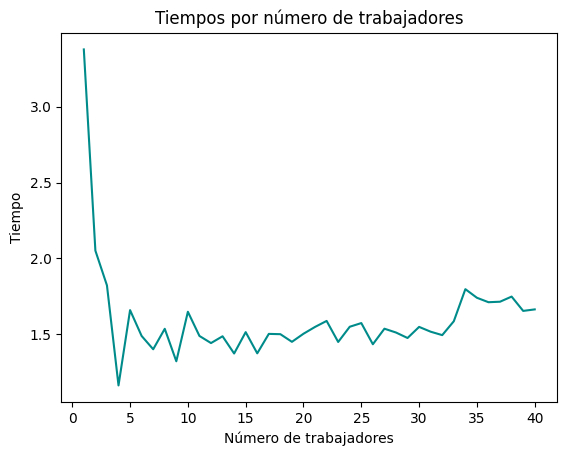

In [16]:
import matplotlib.pyplot as plt

workers_list = [i for i in range(1, 41)]
time_results = []

for workers in workers_list:
    t0 = tm.time()

    parallelProcess(workers, "coordenadas1000.txt") # Utilizamos el archivo de 1000 coordenadas

    t1 = tm.time()

    # Guardamos el tiempo en la lista:
    time_results.append(t1-t0)

# Graficamos:
plt.plot(workers_list, time_results, color="darkcyan")
plt.title("Tiempos por número de trabajadores")
plt.xlabel("Número de trabajadores")
plt.ylabel("Tiempo")
plt.show()

Es interesante comparar el gráfico anterior con el número de núcleos y procesadores lógicos de nuestro computador.

Para terminar, veamos algunos cálculos de métricas relacionadas a la eficiencia paralela que verán más adelante en el curso:

- Speedup: $S_p=T_1/T_p$ con $T_p$ el tiempo de ejecución de los $p$ procesadores.

In [17]:
Sp = [time_results[0]/i for i in time_results[:21]]
Sp

[1.0,
 1.64746084768365,
 1.8546946912617088,
 2.9090063403591517,
 2.037404729215569,
 2.270883528633218,
 2.4132159435144525,
 2.200954638960348,
 2.5581164377935086,
 2.0508358635447355,
 2.270776893400807,
 2.344681843244642,
 2.2740598754803663,
 2.4623794196572177,
 2.232928554149558,
 2.460489843832757,
 2.2501265694934807,
 2.2530935126873137,
 2.33149996659625,
 2.248718472454399,
 2.183324213614982]

- Eficiencia: $E_p=S_p/p$

In [18]:
Ep = [Sp[i-1]/i for i in range(1, len(time_results[:21])+1)]
Ep

[1.0,
 0.823730423841825,
 0.618231563753903,
 0.7272515850897879,
 0.4074809458431138,
 0.37848058810553636,
 0.3447451347877789,
 0.2751193298700435,
 0.28423515975483427,
 0.20508358635447355,
 0.20643426303643697,
 0.19539015360372017,
 0.17492768272925893,
 0.17588424426122984,
 0.14886190360997054,
 0.1537806152395473,
 0.13236038644079298,
 0.12517186181596188,
 0.12271052455769738,
 0.11243592362271995,
 0.10396781969595152]